In [77]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import joblib
import io
import os
import re
import json
import zipfile

In [78]:
# Load feature_df_raw and feature_df_enc
with zipfile.ZipFile(f"../csv_outputs/feature_df_raw.zip") as zf:
    with zf.open("feature_df_raw.csv") as f:
        feature_df_raw = pd.read_csv(f)
with zipfile.ZipFile(f"../csv_outputs/feature_df_enc.zip") as zf:
    with zf.open("feature_df_enc.csv") as f:
        feature_df_enc = pd.read_csv(f)

# **1. Model training, validation & testing**

* Temporal train/validation/test split: 
  * Train on older data (<=2022) 
  * Validate on newer data (2023)
  * Test on newer data (2024-2025)

* Train and compare models based on the following loss functions: 
  * Lin-Lin/Pinball loss (asymmetric) with alpha=0.75
    * Penalise under-predictions more heavily (alpha>0.5) due to budget constraint
  * MSE (symmetric)

* Models:
  * Linear Regression
  * Random Forest (trained on MSE only, Lin-Lin loss is not supported)
  * LightGBM (trained on Lin-Lin and MSE)
  * XGBoost (trained on Lin-Lin and MSE)
  * CatBoost (trained on Lin-Lin and MSE)
  * Ensemble - combined forecasts 
    * Simple average (equal weights)
    * Bates-Granger combination
    * Granger-Ramanathan combination

* Hyperparameter tuning: done using Optuna library

**1a. Train/validation/test split**

In [79]:
TARGET = "real_price"
FEATURES = [c for c in feature_df_raw.columns if c not in (TARGET, "rpi")]

split_index = (2024 - 2017) * 12 # 84: test boundary (Jan 2024)
val_split = split_index - 12 # 72: last 12 months of train used as validation
test_upper = (2026 - 2017) * 12 # 108: Jan 2026 (held out as listings)

# Use raw (non-encoded) training data for XGBoost, CatBoost, LightGBM and baseline median models
train_df = feature_df_raw[feature_df_raw["month_index"] < val_split]
val_df = feature_df_raw[(feature_df_raw["month_index"] >= val_split) &
                        (feature_df_raw["month_index"] < split_index)]
test_df = feature_df_raw[(feature_df_raw["month_index"] >= split_index) & 
                         (feature_df_raw["month_index"] < test_upper)]
X_train_raw, X_val_raw, X_test_raw = train_df[FEATURES], val_df[FEATURES], test_df[FEATURES]
y_train, y_val, y_test = train_df[TARGET], val_df[TARGET], test_df[TARGET]

# CatBoost needs column indices for categorical features
cat_cols = ["town", "flat_type"]
cat_idx = [X_train_raw.columns.get_loc(c) for c in cat_cols]

# Split RPI arrays for conversion to nominal values
rpi_train, rpi_val, rpi_test = train_df["rpi"].values, val_df["rpi"].values, test_df["rpi"].values

RPI_BASE = 100.0
print(f"RPI range in data: {feature_df_raw["rpi"].min():.1f} – {feature_df_raw["rpi"].max():.1f}")

# Use encoded training data for Random Forest (cannot handle string categoricals natively)
train_df_enc = feature_df_enc[feature_df_enc["month_index"] < val_split]
val_df_enc = feature_df_enc[(feature_df_enc["month_index"] >= val_split) &
                               (feature_df_enc["month_index"] < split_index)]
test_df_enc = feature_df_enc[(feature_df_enc["month_index"] >= split_index) &
                             (feature_df_enc["month_index"] < test_upper)]
X_train_enc, X_val_enc, X_test_enc = train_df_enc[FEATURES], val_df_enc[FEATURES], test_df_enc[FEATURES]

print(f"Train: {len(X_train_enc):,} | Val: {len(X_val_enc):,} | Test: {len(X_test_enc):,}")

# Combine training + validation set to refit the final model after hyperparameter tuning
X_trainval_raw = pd.concat([X_train_raw, X_val_raw]).reset_index(drop=True)
X_trainval = pd.concat([X_train_enc, X_val_enc]).reset_index(drop=True)
y_trainval = pd.concat([y_train, y_val]).reset_index(drop=True)

for col in cat_cols:
    X_train_raw[col] = X_train_raw[col].astype("category")
    X_val_raw[col] = X_val_raw[col].astype("category")
    X_test_raw[col] = X_test_raw[col].astype("category")
    X_trainval_raw[col] = X_trainval_raw[col].astype("category")

RPI range in data: 130.8 – 203.7
Train: 143,396 | Val: 25,754 | Test: 52,918


**1b. Loss function & Alpha selection**

The asymmetric Lin-Lin (pinball) loss penalises under- and over-predictions differently:

$$L(e,\alpha) = \begin{cases} \alpha \cdot e & \text{if } e \geq 0 \quad \text{(under-prediction)} \\ (1-\alpha) \cdot |e| & \text{if } e < 0 \quad \text{(over-prediction)} \end{cases}$$

where $\alpha = c_{\text{under}} / (c_{\text{under}} + c_{\text{over}})$ and $e = y_{\text{true}} - \hat{y}$.

**Choosing $\alpha$ in the HDB buyer context:**
- **Under-prediction** ($\hat{y} < \text{actual}$): buyer's budget may be insufficient: more costly
- **Over-prediction** ($\hat{y} > \text{actual}$): within buyer's budget: less costly, but makes flat search slightly more inefficient

As the relative severity of over- vs under-prediction in this context is subjective and there are no defined cost functions, we assume under-prediction is 3x as costly as over-prediction, since buyers would not want to exceed their budget. This is validated (but not determined) by checking that empirical coverage $\approx$ 0.75 on the validation set.

Training objectives:

| Variant | Models | Loss function |
|---|---|---|
| Asymmetric | LightGBM, XGBoost, CatBoost | Lin-Lin loss with $\alpha$ = 0.75 |
| Symmetric | Random Forest*, LightGBM, XGBoost, CatBoost | MSE/RMSE |

*Random Forest is only trained on symmetric loss as asymmetric Lin-Lin loss is not supported

In [80]:
ALPHA = 0.75 # asymmetric: c_under = 3 × c_over

def linlin_loss(y_true, y_pred, alpha=ALPHA):
    errors = y_true - y_pred
    loss = np.where(errors >= 0, alpha * errors, (1 - alpha) * (-errors))
    return loss, loss.mean()

**1c. Model training & hyperparameter tuning**

In [102]:
def to_nominal(real_pred, rpi_series, rpi_base=RPI_BASE):
    return np.array(real_pred) * (np.array(rpi_series) / rpi_base)

def evaluate(name, y_true, y_pred, rpi_series, alpha=ALPHA):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    errors = y_true - y_pred
    linlin = np.mean(np.where(errors >= 0, alpha * errors, (1 - alpha) * (-errors)))
    cov = np.mean(y_true <= y_pred)
    nominal_mae = mean_absolute_error(
        to_nominal(y_true, rpi_series),
        to_nominal(y_pred, rpi_series)
    )
    nominal_rmse = np.sqrt(mean_squared_error(
        to_nominal(y_true, rpi_series), 
        to_nominal(y_pred, rpi_series)
    ))
    print(f"\n{name}")
    print(f"Lin-Lin: {linlin:,.0f}")
    print(f"Coverage: {cov:.3f}")
    print(f"MAE (nominal $): ${nominal_mae:,.0f}")
    print(f"RMSE (nominal $): ${nominal_rmse:,.0f}")
    print(f"MAE (real $): ${mae:,.0f}")
    print(f"RMSE (real $): ${rmse:,.0f}")
    print(f"MAPE: {mape:.2f}%")
    return {"name": name, "Lin-Lin": linlin, "Coverage": cov,
            "MAE_nominal": nominal_mae, "MAE": mae, "RMSE_nominal": nominal_rmse, "RMSE": rmse,
            "MAPE": mape}

In [82]:
# Benchmarks
## Global Median
overall_train_median = train_df[TARGET].median()
global_median_pred = np.full(len(y_test), overall_train_median)
res_global_median = evaluate("Global Median", y_test, global_median_pred, rpi_test)

## Stratified Median (town x flat_type)
group_median_map = (
    train_df.groupby(["town", "flat_type"])[TARGET]
    .median().rename("group_median")
)
stratified_median = (
    test_df[["town", "flat_type"]]
    .join(group_median_map, on=["town", "flat_type"])
    ["group_median"].fillna(overall_train_median).values
)
res_strat_median = evaluate("Stratified Median (town x flat_type)", y_test, stratified_median, rpi_test)


Global Median
Lin-Lin: 39,917
Coverage: 0.524
MAE (nominal $): $149,876
RMSE (nominal $): $196,199
MAE (real $): $76,327
RMSE (real $): $99,816
MAPE: 25.42%

Stratified Median (town x flat_type)
Lin-Lin: 20,230
Coverage: 0.504
MAE (nominal $): $75,692
RMSE (nominal $): $110,064
MAE (real $): $38,540
RMSE (real $): $55,994
MAPE: 11.75%


In [83]:
# Linear Regression (Ridge): symmetric baseline
# No quantile variant exists. Evaluated on both symmetric and asymmetric metrics.

## Validation: fit scaler on train only
scaler_val = StandardScaler()
X_train_scaled = scaler_val.fit_transform(X_train_enc)
X_val_scaled = scaler_val.transform(X_val_enc)

lr_val_model = Ridge(alpha=1.0)
lr_val_model.fit(X_train_scaled, y_train) # train on training set only
lr_val_pred = lr_val_model.predict(X_val_scaled) # predict val

## Final: refit scaler on full train+val
scaler_final = StandardScaler()
X_trainval_scaled = scaler_final.fit_transform(X_trainval) # train on train+val
X_test_scaled = scaler_final.transform(X_test_enc)

lr_model = Ridge(alpha=1.0)
lr_model.fit(X_trainval_scaled, y_trainval)
lr_test_pred = lr_model.predict(X_test_scaled)

res_lr = evaluate("Linear Regression (Ridge)", y_test, lr_test_pred, rpi_test)

from sklearn.metrics import r2_score
r2 = r2_score(y_test, lr_test_pred)
n = len(y_test)
p = X_test_scaled.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1)/(n - p - 1)
print(f"R2: {r2}")
print(f"Adjusted R2: {adj_r2}")


Linear Regression (Ridge)
Lin-Lin: 15,370
Coverage: 0.519
MAE (nominal $): $60,257
RMSE (nominal $): $77,823
MAE (real $): $30,671
RMSE (real $): $39,560
MAPE: 10.36%
R2: 0.8421407317588016
Adjusted R2: 0.8420332653028593


In [84]:
# Random Forest: Symmetric loss only 
# RF cannot use quantile/LinLin loss natively
optuna.logging.set_verbosity(optuna.logging.WARNING)

def rf_objective(trial):
    model = RandomForestRegressor(
        n_estimators=80,
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 3, 12),
        max_features=trial.suggest_float("max_features", 0.3, 0.7),
        max_depth=trial.suggest_int("max_depth", 8, 20),
        n_jobs=-1, random_state=42
    )
    model.fit(X_train_enc, y_train)
    return mean_absolute_error(y_val, model.predict(X_val_enc))

rf_study = optuna.create_study(direction="minimize",
                               sampler=optuna.samplers.TPESampler(seed=42, multivariate=True))
rf_study.optimize(rf_objective, n_trials=15, show_progress_bar=True)
print("Best RF params:", rf_study.best_params)

rf_model_val = RandomForestRegressor(n_estimators=400, **rf_study.best_params,
                                     n_jobs=-1, random_state=42)
rf_model_val.fit(X_train_enc, y_train)
rf_val_pred = rf_model_val.predict(X_val_enc)

rf_model = RandomForestRegressor(n_estimators=400, **rf_study.best_params,
                                 n_jobs=-1, random_state=42)
rf_model.fit(X_trainval, y_trainval)
rf_pred = rf_model.predict(X_test_enc)

res_rf = evaluate("Random Forest (Symmetric)", y_test, rf_pred, rpi_test)

c:\Users\lucil\OneDrive - National University of Singapore\AY2526\AY2526 SEM 2\DSE3101\dse3101 project\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
Best trial: 14. Best value: 12645.3: 100%|██████████| 15/15 [36:37<00:00, 146.53s/it]


Best RF params: {'min_samples_leaf': 3, 'max_features': 0.5454865080358684, 'max_depth': 19}

Random Forest (Symmetric)
Lin-Lin: 5,710
Coverage: 0.591
MAE (nominal $): $25,648
RMSE (nominal $): $36,348
MAE (real $): $13,031
RMSE (real $): $18,407
MAPE: 4.07%


In [85]:
# LightGBM: Asymmetric variant 
def lgb_safe(df):
    df = df.copy()
    df.columns = [re.sub(r"[^A-Za-z0-9_]", "_", c) for c in df.columns]
    return df

X_train_lgb = lgb_safe(X_train_raw)
X_val_lgb = lgb_safe(X_val_raw)
X_test_lgb = lgb_safe(X_test_raw)
X_trainval_lgb = lgb_safe(X_trainval_raw)
cat_cols_lgb = [re.sub(r"[^A-Za-z0-9_]", "_", c) for c in cat_cols]

optuna.logging.set_verbosity(optuna.logging.WARNING)

def lgb_objective(trial):
    model = lgb.LGBMRegressor(
        n_estimators=2000,
        objective="quantile", alpha=ALPHA,
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        num_leaves=trial.suggest_int("num_leaves", 31, 127),
        min_child_samples=trial.suggest_int("min_child_samples", 10, 80),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.5, 15.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        random_state=42, n_jobs=-1
    )
    model.fit(X_train_lgb, y_train, eval_set=[(X_val_lgb, y_val)],
              categorical_feature=cat_cols_lgb,
              callbacks=[lgb.early_stopping(75), lgb.log_evaluation(0)])
    _, pl = linlin_loss(y_val.values, model.predict(X_val_lgb), ALPHA)
    return pl

lgb_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
lgb_study.optimize(lgb_objective, n_trials=15, show_progress_bar=True)
print("Best LGB params:", lgb_study.best_params)

lgb_model_val = lgb.LGBMRegressor(
    n_estimators=2000, objective="quantile", alpha=ALPHA,
    **lgb_study.best_params, random_state=42, n_jobs=-1
)
lgb_model_val.fit(X_train_lgb, y_train, eval_set=[(X_val_lgb, y_val)],
                  categorical_feature=cat_cols_lgb,
                  callbacks=[lgb.early_stopping(75), lgb.log_evaluation(50)])
lgb_val_pred = lgb_model_val.predict(X_val_lgb)
best_lgb_iter = lgb_model_val.best_iteration_
print(f"Best LightGBM iteration: {best_lgb_iter}")

lgb_model = lgb.LGBMRegressor(
    n_estimators=best_lgb_iter, objective="quantile", alpha=ALPHA,
    **lgb_study.best_params, random_state=42, n_jobs=-1
)
lgb_model.fit(X_trainval_lgb, y_trainval, categorical_feature=cat_cols_lgb,
              callbacks=[lgb.log_evaluation(50)])
lgb_pred = lgb_model.predict(X_test_lgb)

res_lgb = evaluate("LightGBM (Asymmetric)", y_test, lgb_pred, rpi_test)

c:\Users\lucil\OneDrive - National University of Singapore\AY2526\AY2526 SEM 2\DSE3101\dse3101 project\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
  0%|          | 0/15 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.168932 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6769
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 36
[LightGBM] [Info] Start training from score 392670.156250
Training until validation scores don't improve for 75 rounds
Did not meet early stopping. Best iteration is:
[1932]	valid_0's quantile: 4818.99


Best trial: 0. Best value: 4818.99:   7%|▋         | 1/15 [01:59<27:55, 119.69s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030006 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6769
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 36
[LightGBM] [Info] Start training from score 392670.156250
Training until validation scores don't improve for 75 rounds
Early stopping, best iteration is:
[748]	valid_0's quantile: 4939.41


Best trial: 0. Best value: 4818.99:  13%|█▎        | 2/15 [02:37<15:26, 71.23s/it] 

...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018541 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6769
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 36
[LightGBM] [Info] Start training from score 392670.156250
Training until validation scores don't improve for 75 rounds
Did not meet early stopping. Best iteration is:
[1992]	valid_0's quantile: 4772.33


Best trial: 11. Best value: 4749.07:  93%|█████████▎| 14/15 [13:26<00:51, 51.35s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020219 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6769
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 36
[LightGBM] [Info] Start training from score 392670.156250
Training until validation scores don't improve for 75 rounds
Did not meet early stopping. Best iteration is:
[1999]	valid_0's quantile: 4817.63


Best trial: 11. Best value: 4749.07: 100%|██████████| 15/15 [14:20<00:00, 57.36s/it]


Best LGB params: {'learning_rate': 0.04314878687306059, 'num_leaves': 103, 'min_child_samples': 20, 'subsample': 0.9607903966782164, 'colsample_bytree': 0.5340184833000602, 'reg_lambda': 1.1619496046220776, 'reg_alpha': 0.004608234147476909}
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002842 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6769
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 36
[LightGBM] [Info] Start training from score 392670.156250
Training until validation scores don't improve for 75 rounds
[50]	valid_0's quantile: 9336.16
[100]	valid_0's quantile: 6209.38
[150]	valid_0's quantile: 5478.83
[200]	valid_0's quantile: 5241.1
[250]	valid_0's quantile: 5124.27
[300]	valid_0's quantile: 5042.26
[350]	valid_0's quantile: 4991.22
[400]	valid_0's quantile: 4954.06
[450]	valid_0's

In [86]:
# LightGBM: Symmetric variant
optuna.logging.set_verbosity(optuna.logging.WARNING)

def lgb_sym_objective(trial):
    model = lgb.LGBMRegressor(
        n_estimators=2000,
        objective="regression",
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        num_leaves=trial.suggest_int("num_leaves", 31, 127),
        min_child_samples=trial.suggest_int("min_child_samples", 10, 80),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.5, 15.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        random_state=42, n_jobs=-1
    )
    model.fit(X_train_lgb, y_train, eval_set=[(X_val_lgb, y_val)],
              categorical_feature=cat_cols_lgb,
              callbacks=[lgb.early_stopping(75), lgb.log_evaluation(0)])
    return mean_absolute_error(y_val, model.predict(X_val_lgb))

lgb_sym_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
lgb_sym_study.optimize(lgb_sym_objective, n_trials=15, show_progress_bar=True)
print("Best LGB sym params:", lgb_sym_study.best_params)

lgb_sym_model_val = lgb.LGBMRegressor(
    n_estimators=2000, objective="regression",
    **lgb_sym_study.best_params, random_state=42, n_jobs=-1
)
lgb_sym_model_val.fit(X_train_lgb, y_train, eval_set=[(X_val_lgb, y_val)],
                      categorical_feature=cat_cols_lgb,
                      callbacks=[lgb.early_stopping(75), lgb.log_evaluation(50)])
lgb_sym_val_pred = lgb_sym_model_val.predict(X_val_lgb)
best_lgb_sym_iter = lgb_sym_model_val.best_iteration_

lgb_sym_model = lgb.LGBMRegressor(
    n_estimators=best_lgb_sym_iter, objective="regression",
    **lgb_sym_study.best_params, random_state=42, n_jobs=-1
)
lgb_sym_model.fit(X_trainval_lgb, y_trainval, categorical_feature=cat_cols_lgb,
                  callbacks=[lgb.log_evaluation(50)])
lgb_sym_pred = lgb_sym_model.predict(X_test_lgb)

res_lgb_sym = evaluate("LightGBM (Symmetric)", y_test, lgb_sym_pred, rpi_test)

c:\Users\lucil\OneDrive - National University of Singapore\AY2526\AY2526 SEM 2\DSE3101\dse3101 project\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
  0%|          | 0/15 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017957 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6769
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 36
[LightGBM] [Info] Start training from score 335309.553833
Training until validation scores don't improve for 75 rounds
Early stopping, best iteration is:
[1130]	valid_0's l2: 2.75794e+08


Best trial: 0. Best value: 11722.2:   7%|▋         | 1/15 [00:26<06:04, 26.03s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020255 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6769
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 36
[LightGBM] [Info] Start training from score 335309.553833
Training until validation scores don't improve for 75 rounds
Early stopping, best iteration is:
[508]	valid_0's l2: 3.05236e+08


Best trial: 0. Best value: 11722.2:  13%|█▎        | 2/15 [00:41<04:14, 19.56s/it]

...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019086 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6769
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 36
[LightGBM] [Info] Start training from score 335309.553833
Training until validation scores don't improve for 75 rounds
Early stopping, best iteration is:
[1750]	valid_0's l2: 2.76754e+08


Best trial: 10. Best value: 11537.1:  93%|█████████▎| 14/15 [06:59<00:33, 33.14s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018051 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6769
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 36
[LightGBM] [Info] Start training from score 335309.553833
Training until validation scores don't improve for 75 rounds
Did not meet early stopping. Best iteration is:
[1996]	valid_0's l2: 2.73751e+08


Best trial: 10. Best value: 11537.1: 100%|██████████| 15/15 [07:36<00:00, 30.42s/it]


Best LGB sym params: {'learning_rate': 0.034907905414608316, 'num_leaves': 118, 'min_child_samples': 70, 'subsample': 0.8737239523738184, 'colsample_bytree': 0.5347932177377854, 'reg_lambda': 0.8392491702129204, 'reg_alpha': 0.00010850871665981005}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016291 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6769
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 36
[LightGBM] [Info] Start training from score 335309.553833
Training until validation scores don't improve for 75 rounds
[50]	valid_0's l2: 8.32546e+08
[100]	valid_0's l2: 4.10412e+08
[150]	valid_0's l2: 3.59065e+08
[200]	valid_0's l2: 3.37346e+08
[250]	valid_0's l2: 3.20091e+08
[300]	valid_0's l2: 3.08195e+08
[350]	valid_0's l2: 2.98977e+08
[400]	valid_0's l2: 2.92755e+08
[450]	valid_0's l2: 2.88815e+08
[500]	valid_0's l2: 2.86233e+08
[550]	valid_0's l2: 2.8

In [87]:
# XGBoost: Asymmetric
optuna.logging.set_verbosity(optuna.logging.WARNING)

def xgb_objective(trial):
    model = xgb.XGBRegressor(
        n_estimators=2000, 
        objective="reg:quantileerror", quantile_alpha=ALPHA,
        enable_categorical=True, tree_method="hist",
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        max_depth=trial.suggest_int("max_depth", 4, 8),
        min_child_weight=trial.suggest_int("min_child_weight", 5, 30),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.5, 15.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        random_state=42, n_jobs=-1, early_stopping_rounds=75 
    )
    model.fit(X_train_raw, y_train, eval_set=[(X_val_raw, y_val)], verbose=False)
    _, pl = linlin_loss(y_val.values, model.predict(X_val_raw), ALPHA)
    return pl

xgb_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
xgb_study.optimize(xgb_objective, n_trials=15, show_progress_bar=True) 
xgb_model_val = xgb.XGBRegressor(
    n_estimators=2000, objective="reg:quantileerror", quantile_alpha=ALPHA,
    enable_categorical=True, tree_method="hist",
    **xgb_study.best_params, random_state=42, n_jobs=-1, early_stopping_rounds=75)
xgb_model_val.fit(X_train_raw, y_train, eval_set=[(X_val_raw, y_val)], verbose=50)
print(f"Best iteration: {xgb_model_val.best_iteration}")
xgb_val_pred = xgb_model_val.predict(X_val_raw)

xgb_model = xgb.XGBRegressor(
    n_estimators=xgb_model_val.best_iteration + 1,
    objective="reg:quantileerror", quantile_alpha=ALPHA,
    enable_categorical=True, tree_method="hist",
    **xgb_study.best_params, random_state=42, n_jobs=-1)
xgb_model.fit(X_trainval_raw, y_trainval, verbose=50)
xgb_pred = xgb_model.predict(X_test_raw)

res_xgb = evaluate("XGBoost (Asymmetric)", y_test, xgb_pred, rpi_test)

c:\Users\lucil\OneDrive - National University of Singapore\AY2526\AY2526 SEM 2\DSE3101\dse3101 project\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
Best trial: 10. Best value: 4701.69: 100%|██████████| 15/15 [30:44<00:00, 122.99s/it]


[0]	validation_0-quantile:32965.01624
[50]	validation_0-quantile:10303.53251
[100]	validation_0-quantile:6405.65744
[150]	validation_0-quantile:5520.23160
[200]	validation_0-quantile:5280.25070
[250]	validation_0-quantile:5159.45244
[300]	validation_0-quantile:5058.48901
[350]	validation_0-quantile:4987.35580
[400]	validation_0-quantile:4939.67841
[450]	validation_0-quantile:4899.14867
[500]	validation_0-quantile:4871.54983
[550]	validation_0-quantile:4852.58157
[600]	validation_0-quantile:4832.94948
[650]	validation_0-quantile:4809.87886
[700]	validation_0-quantile:4795.45098
[750]	validation_0-quantile:4786.51015
[800]	validation_0-quantile:4776.77513
[850]	validation_0-quantile:4768.78604
[900]	validation_0-quantile:4763.05470
[950]	validation_0-quantile:4756.95697
[1000]	validation_0-quantile:4748.87722
[1050]	validation_0-quantile:4746.19645
[1100]	validation_0-quantile:4736.94015
[1150]	validation_0-quantile:4731.97211
[1200]	validation_0-quantile:4730.30859
[1250]	validation_0-q

In [88]:
# XGBoost: Symmetric
optuna.logging.set_verbosity(optuna.logging.WARNING)

def xgb_sym_objective(trial):
    model = xgb.XGBRegressor(
        n_estimators=2000,
        objective="reg:squarederror",
        enable_categorical=True, tree_method="hist",
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        max_depth=trial.suggest_int("max_depth", 4, 8),
        min_child_weight=trial.suggest_int("min_child_weight", 5, 30),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.5, 15.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        random_state=42, n_jobs=-1, early_stopping_rounds=75
    )
    model.fit(X_train_raw, y_train, eval_set=[(X_val_raw, y_val)], verbose=False)
    return mean_absolute_error(y_val, model.predict(X_val_raw))

xgb_sym_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
xgb_sym_study.optimize(xgb_sym_objective, n_trials=15, show_progress_bar=True)

xgb_sym_model_val = xgb.XGBRegressor(
    n_estimators=2000, objective="reg:squarederror",
    enable_categorical=True, tree_method="hist",
    **xgb_sym_study.best_params, random_state=42, n_jobs=-1, early_stopping_rounds=75)
xgb_sym_model_val.fit(X_train_raw, y_train, eval_set=[(X_val_raw, y_val)], verbose=50)
xgb_sym_val_pred = xgb_sym_model_val.predict(X_val_raw)
best_xgb_sym_iter = xgb_sym_model_val.best_iteration

xgb_sym_model = xgb.XGBRegressor(
    n_estimators=best_xgb_sym_iter + 1, objective="reg:squarederror",
    enable_categorical=True, tree_method="hist",
    **xgb_sym_study.best_params, random_state=42, n_jobs=-1)
xgb_sym_model.fit(X_trainval_raw, y_trainval, verbose=50)
xgb_sym_pred = xgb_sym_model.predict(X_test_raw)

res_xgb_sym = evaluate("XGBoost (Symmetric)", y_test, xgb_sym_pred, rpi_test)

c:\Users\lucil\OneDrive - National University of Singapore\AY2526\AY2526 SEM 2\DSE3101\dse3101 project\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
Best trial: 12. Best value: 11646.1: 100%|██████████| 15/15 [10:05<00:00, 40.35s/it]


[0]	validation_0-rmse:96030.89390
[50]	validation_0-rmse:29007.80651
[100]	validation_0-rmse:20044.40395
[150]	validation_0-rmse:18686.62461
[200]	validation_0-rmse:18153.64859
[250]	validation_0-rmse:17810.01242
[300]	validation_0-rmse:17558.61107
[350]	validation_0-rmse:17382.70732
[400]	validation_0-rmse:17236.91318
[450]	validation_0-rmse:17129.45586
[500]	validation_0-rmse:17037.88529
[550]	validation_0-rmse:16972.26677
[600]	validation_0-rmse:16888.83136
[650]	validation_0-rmse:16855.97657
[700]	validation_0-rmse:16824.32398
[750]	validation_0-rmse:16793.48272
[800]	validation_0-rmse:16763.10316
[850]	validation_0-rmse:16734.89009
[900]	validation_0-rmse:16717.69781
[950]	validation_0-rmse:16694.78668
[1000]	validation_0-rmse:16682.08548
[1050]	validation_0-rmse:16656.65502
[1100]	validation_0-rmse:16648.28882
[1150]	validation_0-rmse:16637.28911
[1200]	validation_0-rmse:16619.37873
[1250]	validation_0-rmse:16604.63631
[1300]	validation_0-rmse:16594.28958
[1350]	validation_0-rmse

In [89]:
# CatBoost: Asymmetric
def cb_objective(trial):
    model = CatBoostRegressor(
        iterations=2000,                                         
        loss_function=f"Quantile:alpha={ALPHA}",
        eval_metric=f"Quantile:alpha={ALPHA}",
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        depth=trial.suggest_int("depth", 4, 8),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 15.0, log=True),
        bagging_temperature=trial.suggest_float("bagging_temperature", 0.0, 1.0),
        rsm=trial.suggest_float("rsm", 0.5, 1.0),
        random_seed=42, verbose=False, early_stopping_rounds=75  
    )
    model.fit(X_train_raw, y_train, eval_set=(X_val_raw, y_val),
              cat_features=cat_idx, use_best_model=True)
    _, pl = linlin_loss(y_val.values, model.predict(X_val_raw), ALPHA)
    return pl

cb_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
cb_study.optimize(cb_objective, n_trials=15, show_progress_bar=True)

cb_model_val = CatBoostRegressor(
    iterations=2000,
    loss_function=f"Quantile:alpha={ALPHA}", eval_metric=f"Quantile:alpha={ALPHA}",
    **cb_study.best_params, random_seed=42, verbose=200, early_stopping_rounds=75)
cb_model_val.fit(X_train_raw, y_train, eval_set=(X_val_raw, y_val),
                 cat_features=cat_idx, use_best_model=True)
cb_val_pred = cb_model_val.predict(X_val_raw)
best_cb_iter = cb_model_val.best_iteration_
print(f"Best CatBoost iteration: {best_cb_iter}")

cb_model = CatBoostRegressor(
    iterations=best_cb_iter + 1,
    loss_function=f"Quantile:alpha={ALPHA}", eval_metric=f"Quantile:alpha={ALPHA}",
    **cb_study.best_params, random_seed=42, verbose=200)
cb_model.fit(X_trainval_raw, y_trainval, cat_features=cat_idx)
cb_pred = cb_model.predict(X_test_raw)

res_cb = evaluate("CatBoost (Asymmetric)", y_test, cb_pred, rpi_test)

c:\Users\lucil\OneDrive - National University of Singapore\AY2526\AY2526 SEM 2\DSE3101\dse3101 project\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
  0%|          | 0/15 [00:00<?, ?it/s]

Best trial: 0. Best value: 4763.55: 100%|██████████| 15/15 [1:18:50<00:00, 315.34s/it]


0:	learn: 37370.4683193	test: 32217.8188883	best: 32217.8188883 (0)	total: 363ms	remaining: 12m 6s
200:	learn: 6707.9395474	test: 6042.4449384	best: 6042.4449384 (200)	total: 45.8s	remaining: 6m 50s
400:	learn: 5668.0352430	test: 5350.3418771	best: 5350.3418771 (400)	total: 1m 27s	remaining: 5m 49s
600:	learn: 5260.1009807	test: 5077.3493672	best: 5077.3493672 (600)	total: 2m 10s	remaining: 5m 4s
800:	learn: 5021.1796831	test: 4945.2934829	best: 4945.2934829 (800)	total: 2m 56s	remaining: 4m 23s
1000:	learn: 4848.2041281	test: 4881.1567432	best: 4881.1567432 (1000)	total: 3m 39s	remaining: 3m 38s
1200:	learn: 4712.3329886	test: 4833.3222849	best: 4833.2608056 (1198)	total: 4m 21s	remaining: 2m 54s
1400:	learn: 4604.7656006	test: 4803.2948011	best: 4803.2948011 (1400)	total: 5m 3s	remaining: 2m 9s
1600:	learn: 4513.1797667	test: 4782.9345085	best: 4782.9345085 (1600)	total: 5m 46s	remaining: 1m 26s
1800:	learn: 4436.1521930	test: 4771.6609837	best: 4771.3569020 (1787)	total: 6m 30s	rema

In [90]:
# CatBoost: Symmetric
def cb_sym_objective(trial):
    model = CatBoostRegressor(
        iterations=2000,
        loss_function="RMSE",
        eval_metric="RMSE",
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        depth=trial.suggest_int("depth", 4, 8),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 15.0, log=True),
        bagging_temperature=trial.suggest_float("bagging_temperature", 0.0, 1.0),
        rsm=trial.suggest_float("rsm", 0.5, 1.0),
        random_seed=42, verbose=False, early_stopping_rounds=75,
        thread_count=-1
    )
    model.fit(X_train_raw, y_train, eval_set=(X_val_raw, y_val),
              cat_features=cat_idx, use_best_model=True)
    return mean_absolute_error(y_val, model.predict(X_val_raw))

cb_sym_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
cb_sym_study.optimize(cb_sym_objective, n_trials=15, show_progress_bar=True)

cb_sym_model_val = CatBoostRegressor(
    iterations=2000, loss_function="RMSE", eval_metric="RMSE",
    **cb_sym_study.best_params, random_seed=42, verbose=200, early_stopping_rounds=75)
cb_sym_model_val.fit(X_train_raw, y_train, eval_set=(X_val_raw, y_val),
                     cat_features=cat_idx, use_best_model=True)
cb_sym_val_pred = cb_sym_model_val.predict(X_val_raw)
best_cb_sym_iter = cb_sym_model_val.best_iteration_

cb_sym_model = CatBoostRegressor(
    iterations=best_cb_sym_iter + 1, loss_function="RMSE", eval_metric="RMSE",
    **cb_sym_study.best_params, random_seed=42, verbose=200)
cb_sym_model.fit(X_trainval_raw, y_trainval, cat_features=cat_idx)
cb_sym_pred = cb_sym_model.predict(X_test_raw)

res_cb_sym = evaluate("CatBoost (Symmetric)", y_test, cb_sym_pred, rpi_test)

c:\Users\lucil\OneDrive - National University of Singapore\AY2526\AY2526 SEM 2\DSE3101\dse3101 project\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(


Best trial: 0. Best value: 11575.7: 100%|██████████| 15/15 [1:19:45<00:00, 319.02s/it]


0:	learn: 107391.4083205	test: 94086.1732407	best: 94086.1732407 (0)	total: 166ms	remaining: 5m 32s
200:	learn: 22530.2839114	test: 20386.9163599	best: 20386.9163599 (200)	total: 40.7s	remaining: 6m 3s
400:	learn: 19196.5154387	test: 18410.9283703	best: 18410.9283703 (400)	total: 1m 21s	remaining: 5m 25s
600:	learn: 18022.5635602	test: 17697.4531271	best: 17697.4531271 (600)	total: 1m 59s	remaining: 4m 37s
800:	learn: 17313.6861821	test: 17260.6364288	best: 17260.6364288 (800)	total: 2m 40s	remaining: 4m
1000:	learn: 16837.2003542	test: 16996.0599113	best: 16996.0599113 (1000)	total: 3m 21s	remaining: 3m 20s
1200:	learn: 16446.9351608	test: 16790.8210389	best: 16790.8210389 (1200)	total: 4m	remaining: 2m 40s
1400:	learn: 16113.3583208	test: 16660.3621320	best: 16660.3621320 (1400)	total: 4m 39s	remaining: 1m 59s
1600:	learn: 15827.7783346	test: 16581.3912662	best: 16581.2883759 (1599)	total: 5m 19s	remaining: 1m 19s
1800:	learn: 15579.7613340	test: 16488.1730331	best: 16488.1730331 (18

In [111]:
# Add this block immediately before the ensemble construction cell
winners_pred = {
    "CatBoost": cb_pred, 
    "XGBoost": xgb_pred,
    "LightGBM": lgb_pred
}
winners_val_pred = {
    "CatBoost": cb_val_pred, 
    "XGBoost": xgb_val_pred, 
    "LightGBM": lgb_val_pred
}
winners_model = {
    "CatBoost": cb_model,    
    "XGBoost": xgb_model,    
    "LightGBM": lgb_model
}

In [112]:
# Ensemble predictions: equal, Bates-Granger, Granger-Ramanathan
final_model_names = ["CatBoost", "XGBoost", "LightGBM"]
preds_val = np.stack([winners_val_pred[m] for m in final_model_names], axis=1) 
preds_test = np.stack([winners_pred[m] for m in final_model_names], axis=1) 
y_val_arr = y_val.values

# Equal-weight ensemble
equal_weights = np.ones(3) / 3
equal_pred = preds_test @ equal_weights
res_ens_equal = evaluate("Ensemble (Equal Weights)", y_test, equal_pred, rpi_test)

# Bates-Granger
## Forecast errors on validation set
val_errors = y_val_arr[:, None] - preds_val

## Compute variance (MSE) of errors and invert         
val_mse = np.mean(val_errors ** 2, axis=0)     
inv_mse = 1.0 / val_mse

# Normalise to get weights
bg_weights = inv_mse / inv_mse.sum()
print("\n")
print(f"Bates-Granger weights: { {n: round(w, 3) for n, w in zip(final_model_names, bg_weights)} }")

bg_pred = preds_test @ bg_weights
res_ens_bg = evaluate("Ensemble (Bates-Granger)", y_test, bg_pred, rpi_test)

# Granger-Ramanathan constrained: minimise Lin-Lin (pinball) loss on val, w >= 0, sum(w) = 1
# Uses same loss function (ALPHA=0.75) as model training for internal consistency
def _linlin_val(w):
    errors = y_val_arr - (preds_val @ w)
    return np.mean(np.where(errors >= 0, ALPHA * errors, (1 - ALPHA) * (-errors)))

gr_result = minimize(
    _linlin_val, x0=equal_weights, method="SLSQP",
    bounds=[(0, 1)] * 3,
    constraints={"type": "eq", "fun": lambda w: w.sum() - 1}
)
gr_weights = gr_result.x / gr_result.x.sum()
print("\n")
print(f"Granger-Ramanathan weights: { {n: round(w, 3) for n, w in zip(final_model_names, gr_weights)} }")

gr_pred = preds_test @ gr_weights
res_ens_gr = evaluate("Ensemble (Granger-Ramanathan)", y_test, gr_pred, rpi_test)


Ensemble (Equal Weights)
Lin-Lin: 4,768
Coverage: 0.759
MAE (nominal $): $28,176
RMSE (nominal $): $38,390
MAE (real $): $14,319
RMSE (real $): $19,450
MAPE: 4.52%


Bates-Granger weights: {'CatBoost': np.float64(0.333), 'XGBoost': np.float64(0.337), 'LightGBM': np.float64(0.331)}

Ensemble (Bates-Granger)
Lin-Lin: 4,768
Coverage: 0.759
MAE (nominal $): $28,177
RMSE (nominal $): $38,392
MAE (real $): $14,320
RMSE (real $): $19,451
MAPE: 4.52%


Granger-Ramanathan weights: {'CatBoost': np.float64(0.347), 'XGBoost': np.float64(0.401), 'LightGBM': np.float64(0.252)}

Ensemble (Granger-Ramanathan)
Lin-Lin: 4,769
Coverage: 0.760
MAE (nominal $): $28,221
RMSE (nominal $): $38,437
MAE (real $): $14,342
RMSE (real $): $19,474
MAPE: 4.53%


# **2. Model evaluation**

* Feature importances
* Comparison of model performance to choose final model

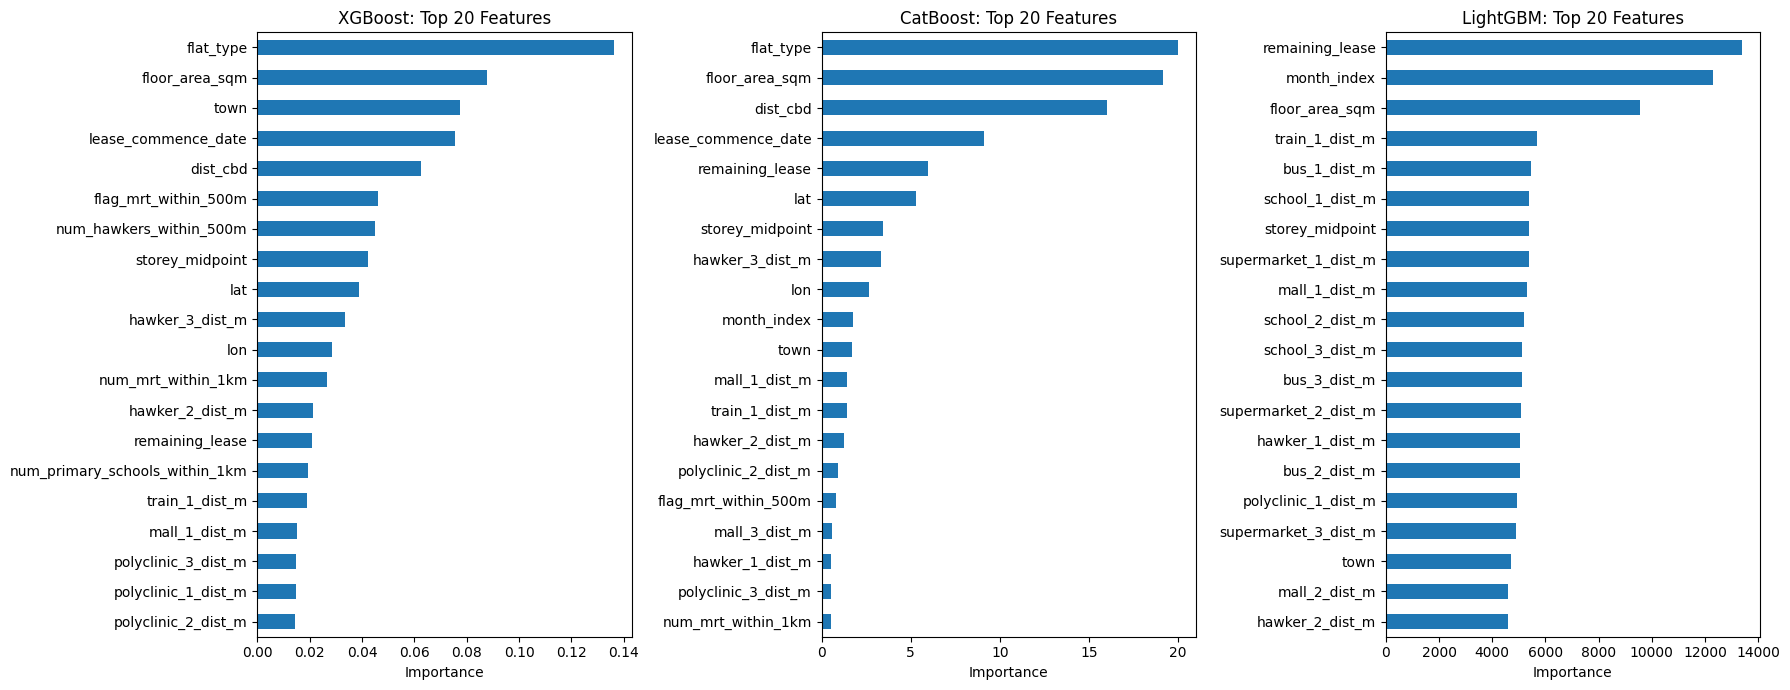

In [113]:
# Feature Importance (top 20)
feature_names_raw = X_train_raw.columns.tolist()
feature_names_lgb = X_train_lgb.columns.tolist()
xgb_imp = pd.Series(xgb_model.feature_importances_, index=feature_names_raw).sort_values(ascending=False)
cb_imp = pd.Series(cb_model.get_feature_importance(), index=feature_names_raw).sort_values(ascending=False)
lgb_imp = pd.Series(lgb_model.feature_importances_, index=feature_names_lgb).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, imp, title in zip(axes, 
                          [xgb_imp, cb_imp, lgb_imp],
                          ["XGBoost", "CatBoost", "LightGBM"]):
    imp.head(20).plot(kind="barh", ax=ax)
    ax.set_title(f"{title}: Top 20 Features")
    ax.invert_yaxis(); ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

In [114]:
# Final Comparison Tables
results_all = [
    res_global_median, res_strat_median,
    res_lr,
    res_rf,
    res_lgb_sym, 
    res_lgb,
    res_xgb_sym,
    res_xgb,
    res_cb_sym, 
    res_cb,
    res_ens_equal, # Equal weights
    res_ens_bg, # Bates-Granger
    res_ens_gr # Granger-Ramanathan (minimises Lin-Lin on val)
]

summary = pd.DataFrame(results_all).set_index("name")

print(f"=== Sorted by Asymmetric Loss ===")
print(summary.sort_values("Lin-Lin").to_string(float_format=lambda x: f"{x:,.2f}"))

# Set WINNING_ENSEMBLE to the model with the lowest loss in the comparison table
WINNING_ENSEMBLE = "equal" 

_ens_map = {
    "equal": (equal_pred, equal_weights),
    "bg": (bg_pred, bg_weights),
    "gr": (gr_pred, gr_weights)
}
opt_pred, opt_weights = _ens_map[WINNING_ENSEMBLE]
print(f"Winning ensemble set to: {WINNING_ENSEMBLE}")


=== Sorted by Asymmetric Loss ===
                                       Lin-Lin  Coverage  MAE_nominal       MAE  RMSE_nominal      RMSE  MAPE
name                                                                                                         
Ensemble (Equal Weights)              4,767.87      0.76    28,175.57 14,319.12     38,390.08 19,450.21  4.52
Ensemble (Bates-Granger)              4,767.98      0.76    28,177.38 14,320.05     38,391.96 19,451.16  4.52
Ensemble (Granger-Ramanathan)         4,769.50      0.76    28,220.99 14,342.40     38,436.64 19,473.99  4.53
CatBoost (Asymmetric)                 4,845.76      0.76    28,586.12 14,530.36     39,045.35 19,783.74  4.57
LightGBM (Asymmetric)                 4,875.81      0.74    28,298.88 14,379.74     38,737.41 19,624.37  4.53
XGBoost (Asymmetric)                  4,881.82      0.76    28,820.59 14,646.82     39,271.74 19,897.25  4.64
XGBoost (Symmetric)                   5,234.45      0.59    23,498.61 11,942.41     33

In [115]:
# Confidence intervals
# CI offsets = percentiles of (actual - predicted) on test set, in real-price space

MODEL_KEY_MAP = {"LightGBM": "lgbm", "XGBoost": "xgb", "CatBoost": "cb"}

def _ci(residuals):
    return {
        "p025_real": float(np.percentile(residuals, 2.5)),
        "p975_real": float(np.percentile(residuals, 97.5)),
    }

ci_offsets = {
    "ensemble_equal": _ci(y_test.values - equal_pred),
    "ensemble_bg": _ci(y_test.values - bg_pred),
    "ensemble_gr": _ci(y_test.values - gr_pred),
    "lgbm": _ci(y_test.values - lgb_pred), 
    "xgb": _ci(y_test.values - xgb_pred),
    "cb":_ci(y_test.values - cb_pred)
}

with open("../json_outputs/ci_offsets.json", "w") as f:
    json.dump(ci_offsets, f, indent=2)
print("Saved keys:", list(ci_offsets.keys()))

Saved keys: ['ensemble_equal', 'ensemble_bg', 'ensemble_gr', 'lgbm', 'xgb', 'cb']


In [116]:
# Save winner models + ensemble weights
os.makedirs("../models", exist_ok=True)

# Individual winner models
cb_model.save_model("../models/cb_model.cbm")
xgb_model.save_model("../models/xgb_model.ubj")
joblib.dump(winners_model["LightGBM"], "../models/lgb_model.joblib")
with zipfile.ZipFile("../models/lgb_model.zip", "w", zipfile.ZIP_DEFLATED, compresslevel=9) as zf:
    zf.write("../models/lgb_model.joblib", "lgb_model.joblib")
print(f"LGB original: {os.path.getsize('../models/lgb_model.joblib') / 1e6:.1f} MB")
print(f"LGB zipped: {os.path.getsize('../models/lgb_model.zip') / 1e6:.1f} MB")
print(f"Saved models: {list(winners_model.keys())}")

# All three ensemble weight arrays
np.save("../models/ensemble_weights_equal.npy", equal_weights)
np.save("../models/ensemble_weights_bg.npy", bg_weights)
np.save("../models/ensemble_weights_gr.npy", gr_weights)

for fname, w in [
    ("equal", equal_weights),
    ("Bates-Granger", bg_weights),
    ("Granger-Ramanathan", gr_weights)
]:
    print(f"{fname}: { {n: round(v, 3) for n, v in zip(final_model_names, w)} }")


LGB original: 15.0 MB
LGB zipped: 5.3 MB
Saved models: ['CatBoost', 'XGBoost', 'LightGBM']
equal: {'CatBoost': np.float64(0.333), 'XGBoost': np.float64(0.333), 'LightGBM': np.float64(0.333)}
Bates-Granger: {'CatBoost': np.float64(0.333), 'XGBoost': np.float64(0.337), 'LightGBM': np.float64(0.331)}
Granger-Ramanathan: {'CatBoost': np.float64(0.347), 'XGBoost': np.float64(0.401), 'LightGBM': np.float64(0.252)}
